In [2]:
import pandas as pd
import os
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
import glob
import warnings
import csv
from collections import OrderedDict
from sklearn.model_selection import train_test_split

In [3]:
import tensorflow as tf
from tensorflow import keras

2026-05-15 16:52:52.327094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778863972.760289      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778863972.878781      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778863973.897593      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778863973.897646      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778863973.897649      57 computation_placer.cc:177] computation placer alr

### Preprocessing

In [4]:
BASE_INPUT_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
CSV_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "csv")
IMAGE_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "jpeg")
BASE_OUTPUT_PATH = "/kaggle/working/"

In [5]:
IMAGE_SIZE = 256
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
RANDOM_SEED = 42

In [6]:
def find_image_in_folder(folder_path):

    if not folder_path or not os.path.isdir(folder_path):
        return None
        
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png')):
                return os.path.join(root, file)
                
    return None

def compute_all_bounding_boxes(mask_path, min_area=100):
    """
    Returns a list of bounding boxes 
    Returns None if mask doesn't exist or is invalid
    """
    if not os.path.exists(mask_path):
        return None

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    _, thresh = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w * h < min_area:
            continue
        boxes.append([x, y, w, h])

    return boxes if boxes else None

def build_metadata_lookup(dicom_info_path, jpeg_base_dir, *args):
    print(f"Building metadata lookup from: {dicom_info_path}")
    master_map = {}
    
    try:
        dicom_info = pd.read_csv(dicom_info_path, dtype=str)
    except FileNotFoundError:
        print(f"Error: Metadata file not found at {dicom_info_path}")
        return master_map

    valid_descriptions = {arg for arg in args}
    filtered_df = dicom_info[dicom_info['SeriesDescription'].isin(valid_descriptions)]

    for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df), desc="Building lookup map"):
        series_desc = row['SeriesDescription'] 
        patient_id_composite = row['PatientID'] 
        
        full_path = None
        
        if 'image_path' in row and pd.notna(row['image_path']):
            rel_path = row['image_path']
            if 'jpeg' in rel_path:
                clean_rel_path = rel_path.split('jpeg')[-1].strip("/\\")
                tmp_path = os.path.join(jpeg_base_dir, clean_rel_path)
            else:
                tmp_path = os.path.join(jpeg_base_dir, rel_path)

            if os.path.exists(tmp_path):
                full_path = tmp_path

        if not full_path:
            series_uid = row['SeriesInstanceUID']
            folder_path = os.path.join(jpeg_base_dir, series_uid)
            full_path = find_image_in_folder(folder_path)
            
        if not full_path or not os.path.exists(full_path): 
            continue

        if patient_id_composite not in master_map:
            master_map[patient_id_composite] = {}
            
        master_map[patient_id_composite][series_desc] = full_path
            
    print(f"Metadata lookup map built. Found {len(master_map)} unique composite keys.")
    return master_map

In [7]:
def BuildMasterDataset(MASTER_LIST_PATH="/kaggle/working/master_dataset.csv", 
                       argument1="cropped images", 
                       argument2="ROI mask images"):
    """
    Build master dataset. If ROI mask is missing:
    - For BENIGN cases: sets mask path to 'n/a' and bbox to 'n/a'
    - For MALIGNANT cases: skips the image entirely
    """
    BASE_INPUT_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
    IMAGE_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "jpeg")
    DICOM_INFO_PATH = os.path.join(BASE_INPUT_PATH, "csv/dicom_info.csv")
    
    INPUT_CSVS = [
        os.path.join(BASE_INPUT_PATH, "csv/mass_case_description_train_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/mass_case_description_test_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/calc_case_description_train_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/calc_case_description_test_set.csv")
    ]

    master_map = build_metadata_lookup(DICOM_INFO_PATH, IMAGE_FOLDER_PATH, argument1, argument2)
    
    if not master_map:
        return

    found_pairs_count = 0
    missing_mask_count = 0
    skipped_malignant_count = 0
    
    with open(MASTER_LIST_PATH, 'w', newline='') as outfile:
        csv_writer = csv.writer(outfile)
        csv_writer.writerow([
            'cropped_image_path', 'roi_mask_path',
            'x_min', 'y_min', 'width', 'height',
            'pathology', 'assessment', 'patient_id', 'series_type', 'mask_status'
        ])

        for filepath in INPUT_CSVS:
            filename = os.path.basename(filepath)
            if not filepath or not os.path.exists(filepath):
                continue
            
            if "mass" in filename.lower():
                type_prefix = "Mass"
            elif "calc" in filename.lower():
                type_prefix = "Calc"
            else:
                continue
                
            if "train" in filename.lower():
                split_prefix = "Training"
            elif "test" in filename.lower():
                split_prefix = "Test"
            else:
                continue
                
            full_prefix = f"{type_prefix}-{split_prefix}"

            with open(filepath, "r") as infile:
                csv_reader = csv.reader(infile)
                header = next(csv_reader)
                
                pathology_idx = header.index('pathology')
                assessment_idx = header.index('assessment')
                patient_id_idx = header.index('patient_id')
                breast_idx = header.index('left or right breast')
                view_idx = header.index('image view')
                abnormality_id_idx = header.index('abnormality id')

                for row in tqdm(csv_reader, desc=f"Processing {filename}"):
                    if not any(row):
                        continue
                    
                    pathology = row[pathology_idx]
                    assessment = row[assessment_idx]
                    patient_id = row[patient_id_idx]
                    side = row[breast_idx]
                    view = row[view_idx]
                    abn_id = row[abnormality_id_idx]
                    
                    try:
                        abn_id_clean = str(int(float(abn_id)))
                    except ValueError:
                        abn_id_clean = str(abn_id).strip()

                    composite_key = f"{full_prefix}_{patient_id}_{side}_{view}_{abn_id_clean}"
                    
                    study_data = master_map.get(composite_key)
                    if not study_data:
                        continue
                    
                    full_crop_path = study_data.get('cropped images')
                    full_mask_path = study_data.get('ROI mask images')
                    
                    if not full_crop_path:
                        continue
                    
                    mask_status = 'valid'
                    
                    if not full_mask_path:
                        pathology_upper = str(pathology).upper()
                        is_benign = 'BENIGN' in pathology_upper and 'MALIGNANT' not in pathology_upper
                        
                        if is_benign:
                            # Set mask path to 'n/a' for benign cases without mask
                            full_mask_path = 'n/a'
                            mask_status = 'n/a'
                            missing_mask_count += 1
                            
                            # Write entry with n/a values
                            csv_writer.writerow([
                                full_crop_path,
                                'n/a',  # roi_mask_path
                                'n/a', 'n/a', 'n/a', 'n/a',  # bbox coordinates
                                pathology,
                                assessment,
                                patient_id,
                                full_prefix,
                                'n/a'  # mask_status
                            ])
                            found_pairs_count += 1
                        else:
                            # Skip malignant cases without masks
                            skipped_malignant_count += 1
                        continue
                    
                    if full_crop_path == full_mask_path and mask_status == 'valid':
                        continue
                    
                    boxes = compute_all_bounding_boxes(full_mask_path, min_area=100)
                    
                    if boxes is None:
                        csv_writer.writerow([
                            full_crop_path,
                            full_mask_path,
                            'n/a', 'n/a', 'n/a', 'n/a',
                            pathology,
                            assessment,
                            patient_id,
                            full_prefix,
                            mask_status
                        ])
                        found_pairs_count += 1
                    else:
                        for (x_min, y_min, width, height) in boxes:
                            csv_writer.writerow([
                                full_crop_path,
                                full_mask_path,
                                x_min, y_min, width, height,
                                pathology,
                                assessment,
                                patient_id,
                                full_prefix,
                                mask_status
                            ])
                            found_pairs_count += 1

    print(f"\n{'='*60}")
    print(f"DATASET BUILD SUMMARY")
    print(f"{'='*60}")
    print(f"Master list saved to: {MASTER_LIST_PATH}")
    print(f"Valid pairs found: {found_pairs_count}")
    print(f"Benign cases without masks (n/a): {missing_mask_count}")
    print(f"Malignant cases skipped (no mask): {skipped_malignant_count}")
    print(f"{'='*60}")

BuildMasterDataset()

Building metadata lookup from: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv


Building lookup map: 100%|██████████| 6814/6814 [00:39<00:00, 171.85it/s]


Metadata lookup map built. Found 3567 unique composite keys.


Processing mass_case_description_train_set.csv: 1318it [01:02, 21.20it/s]
Processing mass_case_description_test_set.csv: 378it [00:17, 21.76it/s]
Processing calc_case_description_train_set.csv: 1546it [01:13, 21.12it/s]
Processing calc_case_description_test_set.csv: 326it [00:00, 732.53it/s]


DATASET BUILD SUMMARY
Master list saved to: /kaggle/working/master_dataset.csv
Valid pairs found: 3445
Benign cases without masks (n/a): 193
Malignant cases skipped (no mask): 127


In [8]:
MASTER_LIST_PATH = "/kaggle/working/master_dataset.csv"

df_master = pd.read_csv(MASTER_LIST_PATH, keep_default_na=False)

unique_patients = df_master["patient_id"].unique()
train_patients, val_patients = train_test_split(
    unique_patients,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_SEED
)

print(f"Splitting {len(unique_patients)} unique patients: {len(train_patients)} for training, {len(val_patients)} for validation.")

Splitting 1510 unique patients: 1208 for training, 302 for validation.


In [9]:
train_df = df_master[df_master['patient_id'].isin(train_patients)].reset_index(drop=True)
val_df = df_master[df_master['patient_id'].isin(val_patients)].reset_index(drop=True)
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GridDistortion(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
   
])

val_transforms = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_57/819158041.py:9: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),


In [10]:
print(f"Total Master CSV : {len(df_master)} lignes")
print(f"Cas valides dans Master : {len(df_master[df_master['mask_status'] == 'valid'])}")
print(f"Cas n/a (sains) dans Master : {len(df_master[df_master['mask_status'] == 'n/a'])}")

print("\n--- Après le Split ---")
print(f"Total Train DF : {len(train_df)} lignes")
print(f"Cas n/a (sains) dans Train : {len(train_df[train_df['mask_status'] == 'n/a'])}")

print(f"Total Val DF : {len(val_df)} lignes")
print(f"Cas n/a (sains) dans Val : {len(val_df[val_df['mask_status'] == 'n/a'])}")

Total Master CSV : 3445 lignes
Cas valides dans Master : 3252
Cas n/a (sains) dans Master : 193

--- Après le Split ---
Total Train DF : 2769 lignes
Cas n/a (sains) dans Train : 154
Total Val DF : 676 lignes
Cas n/a (sains) dans Val : 39


In [11]:
class SegmentationSequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=16, img_size=256, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.img_size = img_size
        self.transforms = transforms

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.batch_size : (idx + 1) * self.batch_size]
        imgs, msks = [], []

        for _, row in batch_df.iterrows():
            image, mask = self._load_data(row)
            imgs.append(image)
            msks.append(mask)

        return np.array(imgs), np.array(msks)

    def _load_data(self, row):
        image = cv2.imread(row["cropped_image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))

        mask_path = row["roi_mask_path"]
        if row["mask_status"] == 'n/a' or mask_path == 'n/a':
            mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        else:
            full_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if full_mask is None:
                mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
            else:
                x_min, y_min = max(0, int(float(row['x_min']))), max(0, int(float(row['y_min'])))
                x_max = min(full_mask.shape[1], x_min + int(float(row['width'])))
                y_max = min(full_mask.shape[0], y_min + int(float(row['height'])))
                mask_crop = full_mask[y_min:y_max, x_min:x_max]
                mask = cv2.resize(mask_crop, (self.img_size, self.img_size))
        
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        mask = mask.astype(np.float32) / 255.0

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=-1)
            
        return image, mask

In [12]:

train_generator = SegmentationSequence(
    dataframe=train_df, 
    batch_size=BATCH_SIZE, 
    img_size=IMAGE_SIZE,
    transforms=train_transforms
)

val_generator = SegmentationSequence(
    dataframe=val_df, 
    batch_size=BATCH_SIZE, 
    img_size=IMAGE_SIZE,
    transforms=val_transforms
)

print(f"Pret ")
print(f"Échantillons : Train={len(train_df)} | Val={len(val_df)}")

Pret 
Échantillons : Train=2769 | Val=676


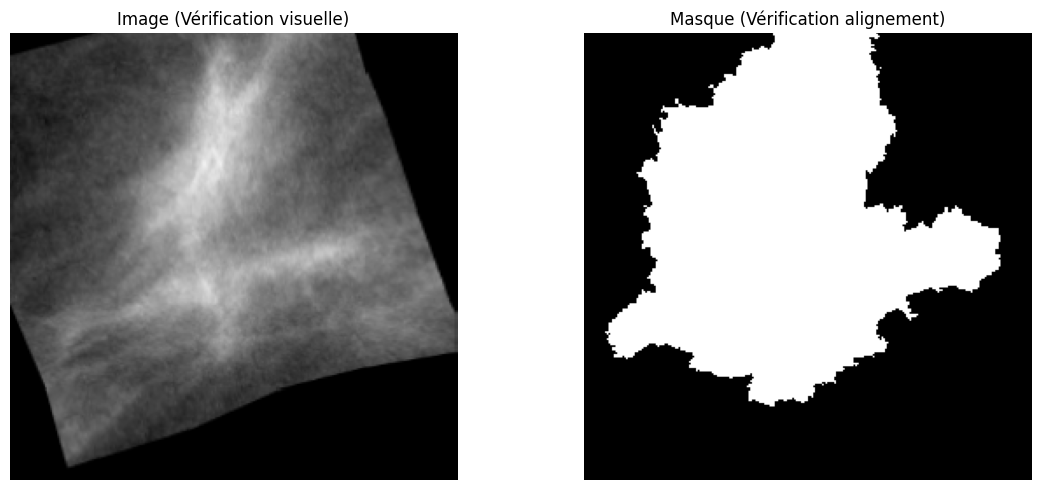

In [13]:
X_batch, y_batch = train_generator[0]

idx = 15
img = X_batch[idx]
mask = y_batch[idx]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = (img * std + mean) 
img_display = np.clip(img_display, 0, 1) 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title("Image (Vérification visuelle)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Masque (Vérification alignement)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Metrics

In [14]:
from tensorflow.keras import backend as K
def dice_coef(y_true,y_pred,smooth=1e-6):
    # we flat out tensor
    y_true_f=K.flatten(K.cast(y_true,'float32'))
    y_pred_f=K.flatten(y_pred)

    #calculate intersection
    intersection=K.sum(y_true_f*y_pred_f)
    return (2.*intersection+smooth) / (K.sum(y_true_f)+K.sum(y_pred_f)+smooth)
def dice_loss(y_true,y_pred):
    return 1-dice_coef(y_true,y_pred)

In [15]:
def specificity(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def f1_score(y_true, y_pred):
    p = keras.metrics.Precision()(y_true, y_pred)
    r = keras.metrics.Recall()(y_true, y_pred)
    return 2 * ((p * r) / (p + r + K.epsilon()))

In [16]:
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = 1.0 - dice_coef(y_true, y_pred)
    return bce + dice_loss

In [17]:
def channel_attention_module(x, ratio=8):
    #On recupere le nombre de filtres
    channels=x.shape[-1]
    #On cree les deux neurones du MLP partage
    shared_layer_one=keras.layers.Dense(channels // ratio, activation="relu", use_bias=False)
    shared_layer_two=keras.layers.Dense(channels, use_bias=False)

    # avgpool 
    avg_pool=keras.layers.GlobalAveragePooling2D()(x)
    avg_pool=keras.layers.Reshape((1,1,channels))(avg_pool)
    avg_out=shared_layer_two(shared_layer_one(avg_pool))

    #maxpool
    max_pool=keras.layers.GlobalMaxPooling2D()(x)
    max_pool=keras.layers.Reshape((1,1,channels))(max_pool)
    max_out=shared_layer_two(shared_layer_one(max_pool))

    #Addition et Sigmoide
    cbam_feature=keras.layers.Add()([avg_out,max_out])
    cbam_feature=keras.layers.Activation('sigmoid')(cbam_feature)

    #Multiplication en sortie
    return keras.layers.multiply([x,cbam_feature])

In [18]:
from keras import ops
def spatial_attention_module(x):
    #
    avg_pool = ops.mean(x,axis=-1,keepdims=True)
    max_pool= ops.max(x,axis=-1,keepdims=True)

    #concatenation
    concat=keras.layers.Concatenate(axis=-1)([avg_pool, max_pool])

    #7x7 filter and sigmoid
    cbam_feature=keras.layers.Conv2D(
        filters=1, kernel_size=7, strides=1,
        padding="same", activation="sigmoid", use_bias=False
    )(concat)

    #muliply and return
    return keras.layers.multiply([x,cbam_feature])

In [19]:
def cbam_block(x,ratio=8):
    x=channel_attention_module(x,ratio)
    x=spatial_attention_module(x)
    return x

### Model

In [21]:
img_size=(256,256)
def cbam_attention_unet(img_size, num_classes):
    inputs=keras.Input(shape=img_size+(3,))
    x=keras.layers.Rescaling(1./255)(inputs)
    c1=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(x)
    c1=keras.layers.BatchNormalization()(c1)
    c1=keras.layers.Dropout(0.1)(c1)
    c1=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(c1)
    c1=keras.layers.BatchNormalization()(c1)
    p1=keras.layers.MaxPooling2D((2,2))(c1)

    c2=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(p1)
    c2=keras.layers.BatchNormalization()(c2)
    c2=keras.layers.Dropout(0.1)(c2)
    c2=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(c2)
    c2=keras.layers.BatchNormalization()(c2)
    p2=keras.layers.MaxPooling2D((2,2))(c2)

    c3=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(p2)
    c3=keras.layers.BatchNormalization()(c3)
    c3=keras.layers.Dropout(0.2)(c3)
    c3=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(c3)
    c3=keras.layers.BatchNormalization()(c3)
    p3=keras.layers.MaxPooling2D((2,2))(c3)

    c4=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(p3)
    c4=keras.layers.BatchNormalization()(c4)
    c4=keras.layers.Dropout(0.2)(c4)
    c4=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(c4)
    c4=keras.layers.BatchNormalization()(c4)
    p4=keras.layers.MaxPooling2D((2,2))(c4)

    c5=keras.layers.Conv2D(256,3,activation="relu", kernel_initializer="he_normal", padding="same")(p4)
    c5=keras.layers.BatchNormalization()(c5)
    c5=keras.layers.Dropout(0.3)(c5)
    c5=keras.layers.Conv2D(256,3,activation="relu", kernel_initializer="he_normal", padding="same")(c5)
    c5=keras.layers.BatchNormalization()(c5)
    c5=cbam_block(c5)

    u6=keras.layers.Conv2DTranspose(128,(2,2),strides=(2,2),padding="same")(c5)
    u6=keras.layers.concatenate([u6,c4])
    c6=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(u6)
    c6=keras.layers.Dropout(0.2)(c6)
    c6=keras.layers.Conv2D(128,3,activation="relu", kernel_initializer="he_normal", padding="same")(c6)

    u7=keras.layers.Conv2DTranspose(64,(2,2),strides=(2,2),padding="same")(c6)
    u7=keras.layers.concatenate([u7,c3])
    c7=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(u7)
    c7=keras.layers.Dropout(0.2)(c7)
    c7=keras.layers.Conv2D(64,3,activation="relu", kernel_initializer="he_normal", padding="same")(c7)

    u8=keras.layers.Conv2DTranspose(32,(2,2),strides=(2,2),padding="same")(c7)
    u8=keras.layers.concatenate([u8,c2])
    c8=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(u8)
    c8=keras.layers.Dropout(0.1)(c8)
    c8=keras.layers.Conv2D(32,3,activation="relu", kernel_initializer="he_normal", padding="same")(c8)

    u9=keras.layers.Conv2DTranspose(16,(2,2),strides=(2,2),padding="same")(c8)
    u9=keras.layers.concatenate([u9,c1])
    c9=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(u9)
    c9=keras.layers.Dropout(0.1)(c9)
    c9=keras.layers.Conv2D(16,3,activation="relu", kernel_initializer="he_normal", padding="same")(c9)

    outputs=keras.layers.Conv2D(1,(1,1),activation="sigmoid")(c9)
    model=keras.Model(inputs,outputs)
    return model

model=cbam_attention_unet(img_size,1)
model.summary()
    

I0000 00:00:1778864732.396938      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778864732.402869      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 1,961,555 (7.48 MB)

 Trainable params: 1,959,571 (7.48 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [24]:
def pure_dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


In [25]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
    loss=pure_dice_loss,
    metrics= ["accuracy",
              keras.metrics.Precision(name='precision'),
              keras.metrics.Recall(name='recall'), 
              specificity, 
              dice_coef])

### Training

In [26]:
callbacks=[
    keras.callbacks.ModelCheckpoint("DDSM_CBAM_UNet.keras",
                                    save_best_only=True),
    keras.callbacks.EarlyStopping(
        patience=10, monitor="val_loss"),
    
    keras.callbacks.ReduceLROnPlateau(
        factor=0.2, patience=5, monitor="val_loss")
]
history=model.fit(train_generator,
                  epochs=50,
                  batch_size=64,
                  validation_data=(val_generator),
                  callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1778864804.856892     204 service.cc:152] XLA service 0x786e34029220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778864804.856936     204 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778864804.856940     204 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778864808.390050     204 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 17:06:55.221838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 17:06:55.366020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 17:06:57.747845: E external/local_xl

136/174 ━━━━━━━━━━━━━━━━━━━━ 27s 716ms/step - accuracy: 0.6721 - dice_coef: 0.7629 - loss: 0.2371 - precision: 0.6653 - recall: 0.9493 - specificity: 0.2267

2026-05-15 17:09:03.786267: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 17:09:04.076753: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 17:09:04.312023: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.29 = (f32[1,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,128,128]{3,2,1,0} %bitcast.49108, f32[32,64,3,3]{3,2,1,0} %bitcast.41651), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/functional_1/conv2d_15_1/convolution/Conv2DBackpropInput" source_file="/

174/174 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.6825 - dice_coef: 0.7663 - loss: 0.2327 - precision: 0.6721 - recall: 0.9487 - specificity: 0.2630 - val_accuracy: 0.6830 - val_dice_coef: 0.7664 - val_loss: 0.2200 - val_precision: 0.6651 - val_recall: 0.9929 - val_specificity: 0.1773 - learning_rate: 5.0000e-04
Epoch 2/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 127s 729ms/step - accuracy: 0.7746 - dice_coef: 0.8036 - loss: 0.1945 - precision: 0.7540 - recall: 0.9199 - specificity: 0.6011 - val_accuracy: 0.7020 - val_dice_coef: 0.7755 - val_loss: 0.2107 - val_precision: 0.6803 - val_recall: 0.9875 - val_specificity: 0.2413 - learning_rate: 5.0000e-04
Epoch 3/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 123s 706ms/step - accuracy: 0.7877 - dice_coef: 0.8034 - loss: 0.1884 - precision: 0.7643 - recall: 0.9223 - specificity: 0.6351 - val_accuracy: 0.7291 - val_dice_coef: 0.7879 - val_loss: 0.1981 - val_precision: 0.7040 - val_recall: 0.9777 - val_specificity: 0.3334 - learning_rate: 5.0000e-04
Epoch 4/50
1

### Visualization 

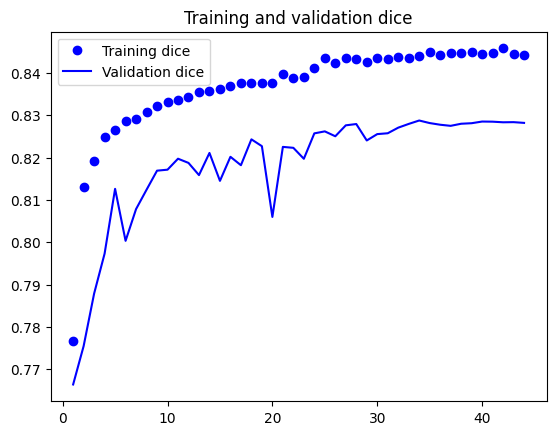

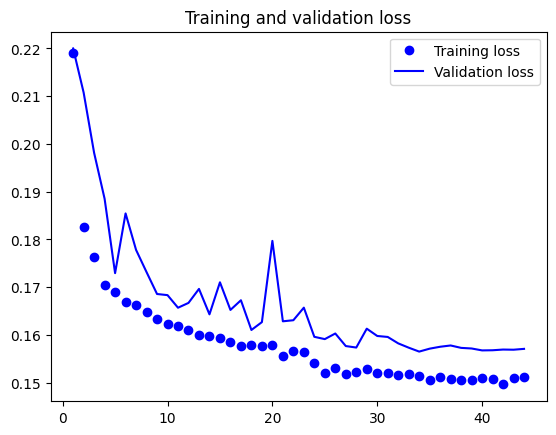

In [27]:
dice = history.history["dice_coef"]
val_dice = history.history["val_dice_coef"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(dice) + 1)
plt.plot(epochs, dice, "bo", label="Training dice")
plt.plot(epochs, val_dice, "b", label="Validation dice")
plt.title("Training and validation dice")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


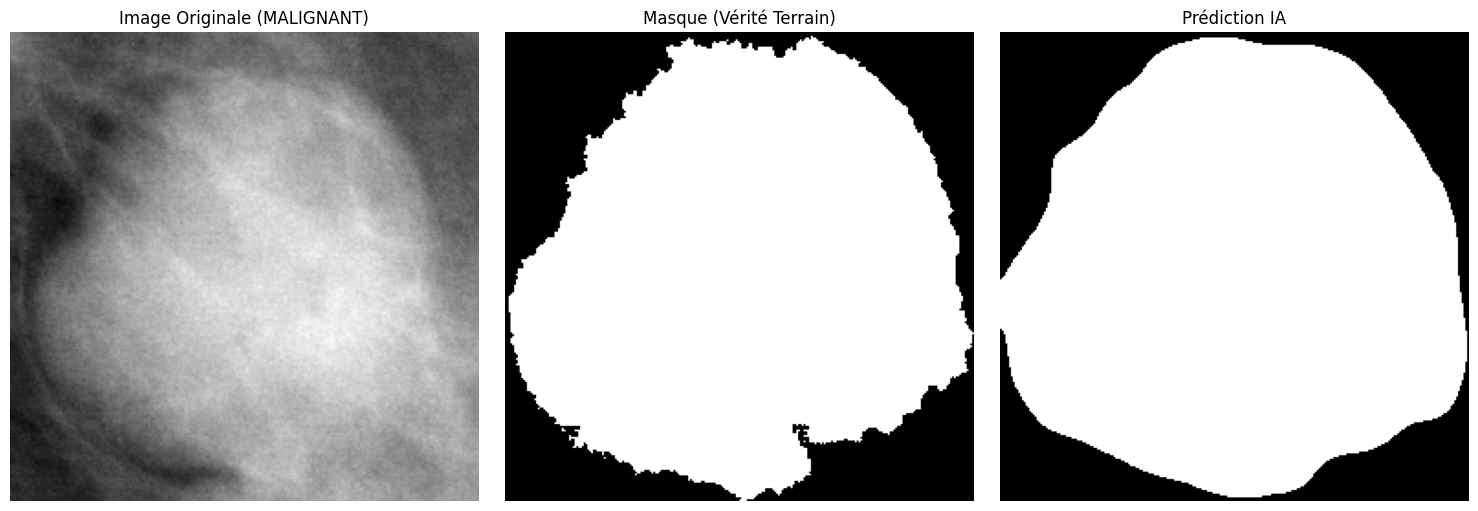

In [31]:
idx = 10
IMAGE_SIZE = 256 

img_path_to_test = val_df['cropped_image_path'].iloc[idx]
msk_path_to_test = val_df['roi_mask_path'].iloc[idx]

raw_img = cv2.imread(img_path_to_test)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (IMAGE_SIZE, IMAGE_SIZE))

raw_msk = cv2.imread(msk_path_to_test, cv2.IMREAD_GRAYSCALE)

x_min, y_min = int(float(val_df['x_min'].iloc[idx])), int(float(val_df['y_min'].iloc[idx]))
w, h = int(float(val_df['width'].iloc[idx])), int(float(val_df['height'].iloc[idx]))
raw_msk = raw_msk[y_min:y_min+h, x_min:x_min+w]

raw_msk_resized = cv2.resize(raw_msk, (IMAGE_SIZE, IMAGE_SIZE))
_, raw_msk_resized = cv2.threshold(raw_msk_resized, 127, 255, cv2.THRESH_BINARY)

transformed = val_transforms(image=raw_img)
img_for_model = transformed["image"]

preds = model.predict(np.expand_dims(img_for_model, 0))

if isinstance(preds, list):
    pred_final = preds[1][0] 
else:
    pred_final = preds[0]

pred_mask = (pred_final > 0.5).astype("uint8")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(raw_img)
plt.title(f"Image Originale ({val_df['pathology'].iloc[idx]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(raw_msk_resized, cmap="gray")
plt.title("Masque (Vérité Terrain)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask.squeeze() * 255, cmap="gray")
plt.title("Prédiction IA")
plt.axis("off")

plt.tight_layout()
plt.show()

### Evaluation

In [32]:
model.evaluate(val_generator)

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 479ms/step - accuracy: 0.8554 - dice_coef: 0.8910 - loss: 0.1084 - precision: 0.8402 - recall: 0.9533 - specificity: 0.6904


[0.15708725154399872,
 0.8130844235420227,
 0.8038802146911621,
 0.9272411465644836,
 0.6539121866226196,
 0.828210711479187]